In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

In [4]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [5]:
nav.head()
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [8]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [ ]:
#nav values showed strong growth during the 2023 bull market and moderate corrections during 2024.
nav['date'] = pd.to_datetime(nav['date'])

fig = px.line(
    nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='nav Trend Analysis'
)

fig.show()

In [15]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [18]:
aum['date'] = pd.to_datetime(aum['date'])
aum['Year'] = aum['date'].dt.year

In [19]:
aum[['date','Year']].head()

,date,Year
0,2022-03-31,2022
1,2022-03-31,2022
2,2022-03-31,2022
3,2022-03-31,2022
4,2022-03-31,2022


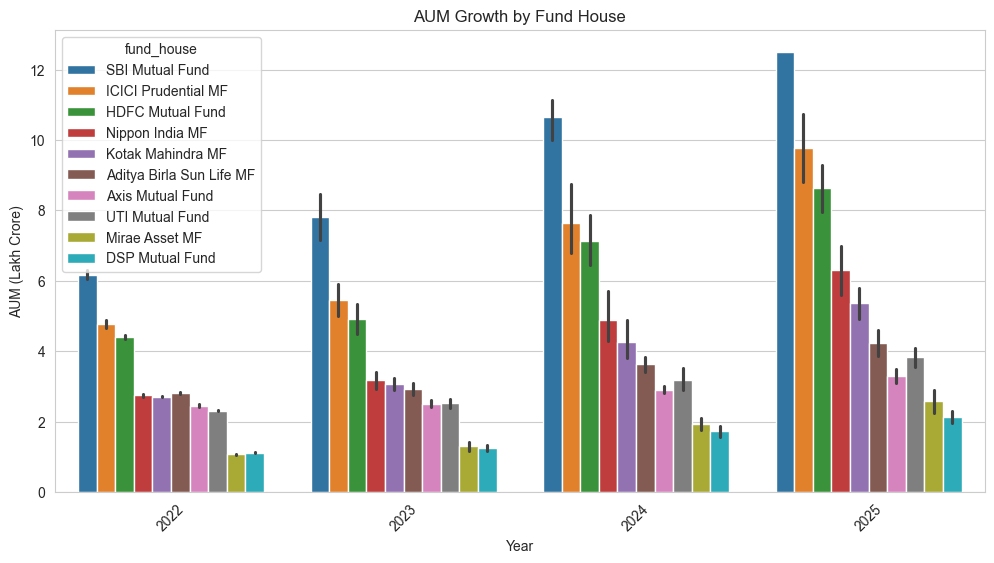

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x='Year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)

plt.show()

In [22]:
sbi = aum[aum['fund_house']=="SBI"]
print(sbi)

Empty DataFrame
Columns: [date, fund_house, aum_lakh_crore, aum_crore, num_schemes, Year]
Index: []


In [24]:
sip['month'] = pd.to_datetime(sip['month'])

In [28]:
sip['month'] = pd.to_datetime(sip['month'])

In [29]:
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='SIP Inflow Over Time'
)

fig.show()

In [30]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

In [31]:
sip['month'] = pd.to_datetime(sip['month'])

In [32]:
import plotly.express as px

fig = px.line(
    sip,
    x='month',
    y='active_sip_accounts_crore',
    title='Active SIP Accounts Trend Over Time'
)

fig.show()

In [33]:
import plotly.express as px

fig = px.line(
    sip,
    x='month',
    y='yoy_growth_pct',
    title='YOY Growth Percentage Trend'
)

fig.show()

In [37]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='object')


In [38]:
pivot = category.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns='month'
)

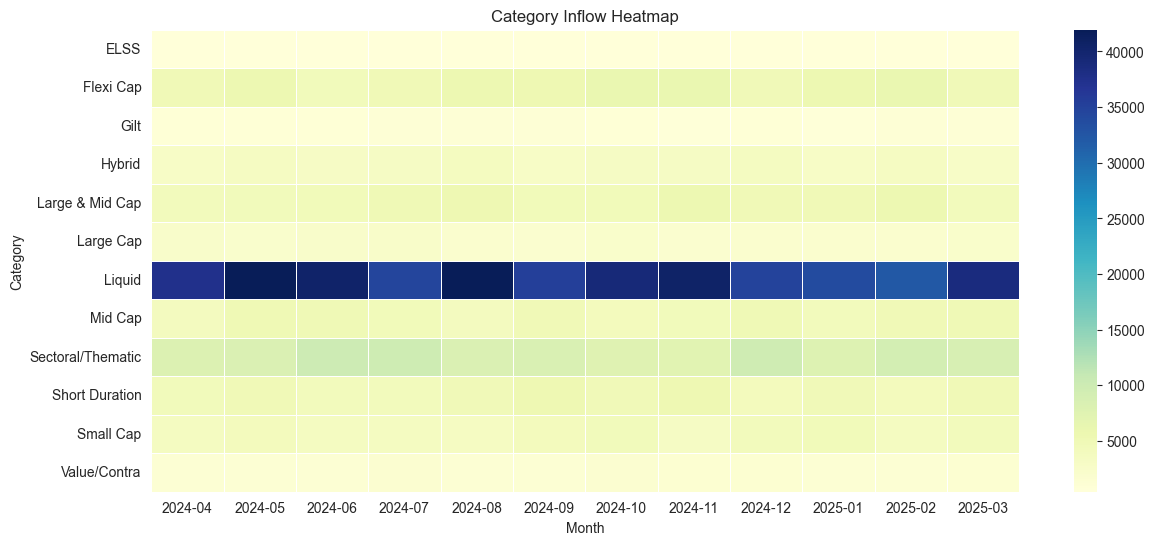

In [39]:
plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap='YlGnBu',
    annot=False,        # avoids clutter
    linewidths=0.5      # makes grid clearer
)

plt.title("Category Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

In [42]:
print(investor.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


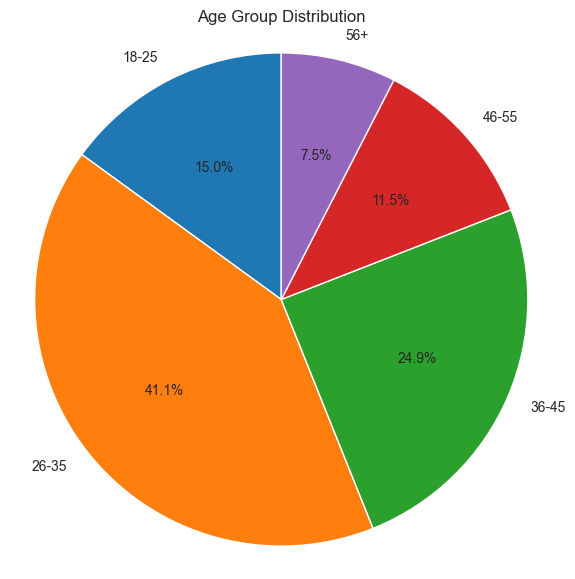

In [43]:
age_data = investor.groupby('age_group')['investor_id'].count()

plt.figure(figsize=(7,7))

plt.pie(
    age_data,
    labels=age_data.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Age Group Distribution")
plt.axis('equal')

plt.show()

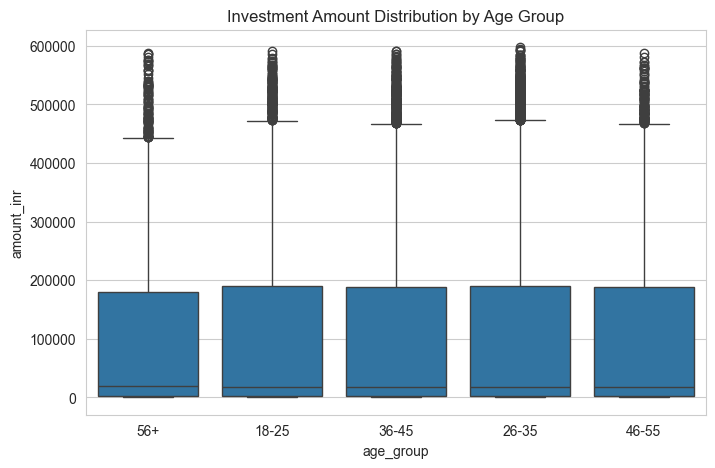

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=investor,
    x='age_group',
    y='amount_inr'
)

plt.title("Investment Amount Distribution by Age Group")
plt.show()

In [47]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'plt', 'sns', 'px', 'go', '_i2', '_i3', '_i4', 'nav', 'aum', 'sip', 'category', 'folio', 'performance', 'investor', 'portfolio', 'benchmark', '_i5', '_i6', '_i7', '_i8', '_i9', '_i10', '_i11', '_i12', 'fig', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_19', '_i20', '_i21', '_i22', 'sbi', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i30', '_30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', '_i38', 'pivot', '_i39', '_i40', '_i41', '_i42', '_i43', 'age_data', '_i44', '_i45', '_i46', '_i47'])


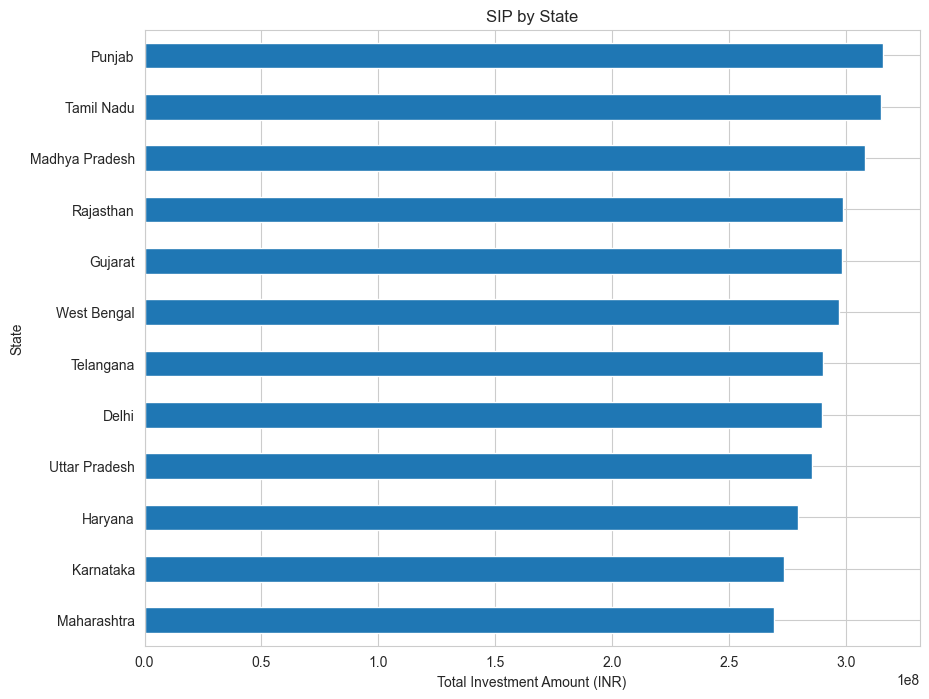

In [48]:
state_data = investor.groupby('state')['amount_inr'].sum()

state_data.sort_values().plot(
    kind='barh',
    figsize=(10,8)
)

plt.title("SIP by State")
plt.xlabel("Total Investment Amount (INR)")
plt.ylabel("State")

plt.show()

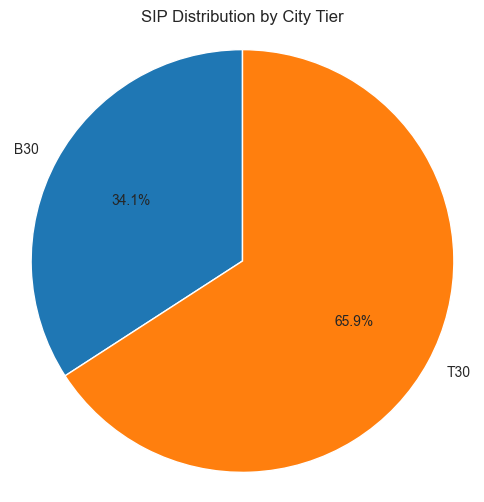

In [49]:
tier_data = investor.groupby('city_tier')['amount_inr'].sum()

plt.figure(figsize=(6,6))

plt.pie(
    tier_data,
    labels=tier_data.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("SIP Distribution by City Tier")
plt.axis('equal')

plt.show()

In [54]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


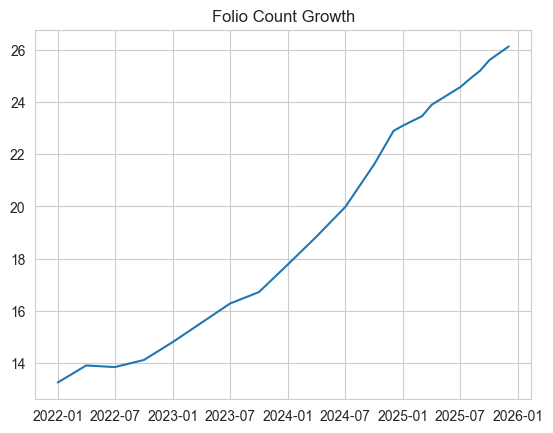

In [55]:
folio['month'] = pd.to_datetime(folio['month'])
folio = folio.sort_values('month')

plt.plot(folio['month'], folio['total_folios_crore'])

plt.title("Folio Count Growth")
plt.show()

In [57]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [58]:
nav['date'] = pd.to_datetime(nav['date'])

pivot_nav = nav.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

returns = pivot_nav.pct_change()

corr = returns.corr()


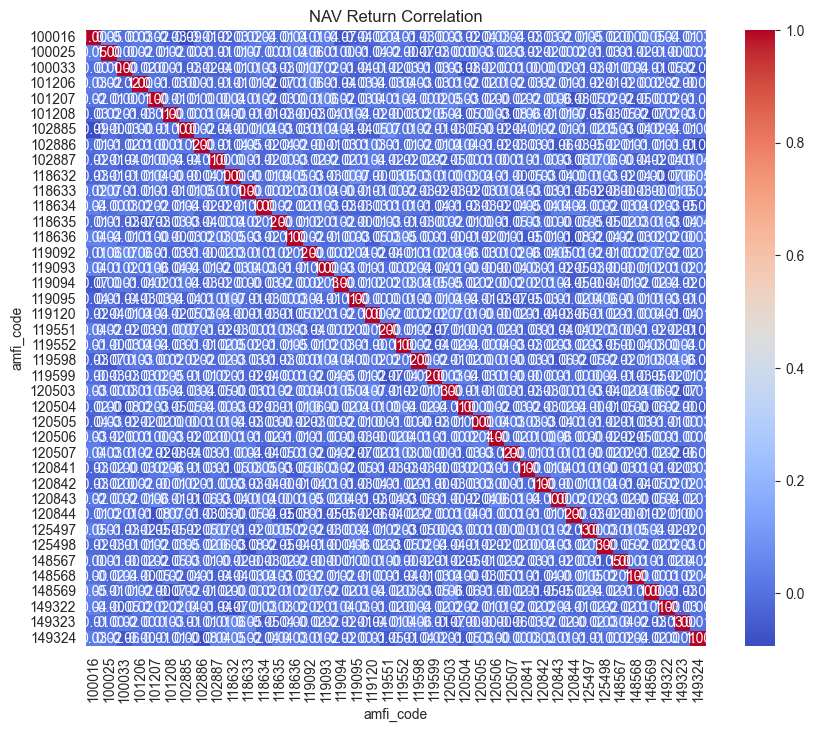

In [59]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("NAV Return Correlation")
plt.show()

In [60]:
#SIP inflows consistently increased over the study period.
 #Dec 2025 recorded the highest SIP inflow.
 #Younger investors contributed the largest share of SIPs.
 #Metro cities generated most investments.
 #Folio counts doubled from 2022 to 2025.
 #Equity funds showed strong positive correlations.
 #IT and Banking sectors dominated allocations.
 #Retail participation increased significantly post-2023.

In [61]:
plt.savefig("chart1.png")

<Figure size 640x480 with 0 Axes>

In [1]:
# run_pipeline.py

"""
Master execution script for Bluestock Mutual Fund Capstone Project.
Runs ETL, EDA, and Performance Analysis sequentially.
"""

import os

os.system("python etl.py")
os.system("python eda.py")
os.system("python performance_analysis.py")

print("Pipeline executed successfully!")

Pipeline executed successfully!
